# Wave-current interaction
In this example, a curved floating bridge is exposed to waves and current. The wave-current interaction effects are dealt with in the same way as in [Fredriksen et al. (2024)](https://www.researchgate.net/profile/Arnt-Fredriksen/publication/386453916_On_the_wave-current_interaction_effect_on_linear_motion_for_floating_bridges/links/6751a40fabddbb448c65cbef/On-the-wave-current-interaction-effect-on-linear-motion-for-floating-bridges.pdf), and is divided into two effects:

* Single-point wavelength shift
* Global modification of dispersion relation

Note that static effects from current are not dealt with in WAWI.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from wawi.model import Model, Windstate, Seastate

# Import of WAWI-model
First, the model of the simple curved floating bridge (defined in the model generation examples) is imported. Thereafter, the number of dry modes is defined together with the frequency axes of the FRF (`omega`) of the combined system and the hydrodynamics (`omega_hydro`).

In [2]:
# Import model
model = Model.from_wwi('./input/model_curved.wwi')
model.aero = None # remove aero model

model.n_modes = 50      # define number of dry modes

# Define omega for FRF of system and aerodynamics
omega = np.arange(0.001, 2, 0.005)
omega_hydro = np.arange(0.001, 2, 0.05)

## Defining `Seastate`
The sea state is defined either directly from initiation of the `Seastate` object (or by importing a json file). The resulting `seastate` object is thereafter assigned to the model using the `assign_seastate` method. To

In [3]:
# Define Seastate  (JONSWAP 1d wave spectrum and cos2s distribution) either from direct initiation of object
# JONSWAP parameters
Hs = 2.1
Tp = 8.3
gamma = 8

# Cos-2s parameters
s = 12
theta0 = 90.0

# Current parameters
thetaU = 80.0
U = 1.0

# Seastate generation
seastate = Seastate(Tp, Hs, gamma, theta0, s, U=1.0, thetaU=80.0)

# or from json
seastate = Seastate.from_json('./input/seastate_example_current.json')

# Apply seastate to model
model.assign_seastate(seastate)

## Response prediction
To predict the response when including currents, a couple of parameters are useful to pay attention to. When creating pontoons, each pontoon can be specified whether or not to have these two effects:

* Current causes Doppler-wavelength shift of wave excitation transfer function, set by a boolean value of the attribute `current_affects_Q` of the pontoon object (default is `True`)
* Current causes global modification of dispersion relation, set by a boolean value of the attribute `current_affects_k` of the pontoon object (default is `True`)

These can also be set when when assigning the seastate, by the `pontoon_options` settings (which are directly passed to all initiations of pontoon objects). These can also be defined in the json-file for the seastate using a dict with key `pontoon_options`. 

To modify it ad hoc, to investigate the consequences of the different effects, they can easily be modified following either of these approaches:

```python
model.seastate.pontoon_options['current_affects_Q'] = False
model.assign_seastate(model.seastate)
```

or 


```python
model.hydro.assign_to_pontoons(current_affects_Q=False)
```

In [7]:
# With currents
model.run_freqsim(omega, omega_hydro=omega_hydro, print_progress=False)
resp_std_current = model.get_result_std(key='girder_forces')          # standard deviation

# Without current
seastate.U = 0    # deactivating current; alternatively we could have used model.hydro.assign_to_pontoons(current_affects_Q=False, current_affects_k=False)
model.assign_seastate(seastate)
model.run_freqsim(omega, omega_hydro=omega_hydro, print_progress=False)
resp_std_nocurrent = model.get_result_std(key='girder_forces')          # standard deviation

## Result plots
In the following code cell, the standard deviations of selected moments and forces along the girder are plotted (with and without current):

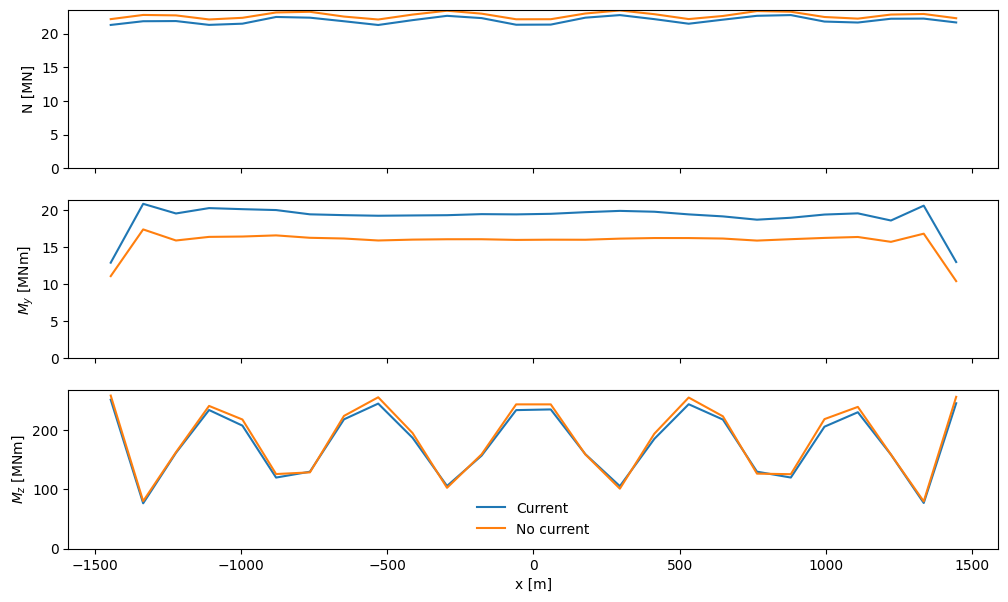

In [8]:
# Plot standard deviations
legend_ax = []
comps = {'N [MN]':0, '$M_y$ [MNm]':4, '$M_z$ [MNm]':5}
arclength_girder_force = model.modal_dry.phi_x['girder_forces'][:, 0]

fig,ax = plt.subplots(nrows=len(comps), sharex=True, figsize=[12,7])
if np.ndim(ax)==0:
    ax = [ax]

for ix, comp in enumerate(comps):
    comp_ix = comps[comp]
    ax[ix].set_ylabel(comp)
    ax[ix].plot(arclength_girder_force, resp_std_current[comp_ix::6]/1e6, label='Current')
    ax[ix].plot(arclength_girder_force, resp_std_nocurrent[comp_ix::6]/1e6, label='No current')
    ax[ix].set_ylim(bottom=0)

ax[-1].legend(frameon=False)
    
ax[-1].set_xlabel('x [m]');